In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import gower
import json
import joblib
import prince
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from kmodes.kprototypes import KPrototypes
from kneed import KneeLocator
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from src.data.processed_data import get_fe_weighted_data
from src.data.processed_data import get_fe_ohe_data
from src.data.processed_data import get_validated_data
from src.visualization.plots import make_plot
from src.visualization.plots import multiple_scatterplot
from src.utils.config import (
    EDA_OUTPUT_PARAMS_PATH,
    FE_OUTPUT_PARAMS_PATH,
    FSTMODEL_OUTPUT_PLOTS_PATH,
    SNDMODEL_OUTPUT_PLOTS_PATH,
    FE_OUTPUT_SCALER_PATH,
    WEIGHTED_DATAFRAME_LABELLED,
    WEIGHTED__MODEL_PATH,
    OHE_DATAFRAME_LABELLED,
    OHE_MODEL_PATH,
)

In [ ]:
# Add load params at processed_data... and change name...
weighted_data = get_fe_weighted_data()
ohe_data = get_fe_ohe_data()
validated_data = get_validated_data()
validated_data = validated_data[["price", "recommendations"]]
discrete_variables = pd.DataFrame(validated_data["price"] == 0)
discrete_variables["recommendations"] = validated_data["recommendations"] > 100
numeric_cols = discrete_variables.columns

with open(EDA_OUTPUT_PARAMS_PATH, "r", encoding="utf-8") as file:
    eda_output = json.load(file)
with open(FE_OUTPUT_PARAMS_PATH, "r", encoding="utf-8") as file:
    fe_output = json.load(file)
genres = ohe_data[fe_output["genres"]].reset_index(drop=True)
categories = ohe_data[fe_output["categories"]].reset_index(drop=True)
categorical_cols = np.concat([genres.columns, categories.columns])
categorical_values = [ohe_data.columns.get_loc(column) for column in categorical_cols]

# First Model Analysis and Training
- Weighted genres and categories
- K-means model
- PCA Visualization

Total variance explained by PC1+PC2+PC3: 0.30852282
Variance explained by each Principal Component: [0.13096902 0.09305187 0.08450194 0.08002494 0.07327636 0.06621873
 0.06118968 0.05434614 0.04913573 0.04821097]
Accumulated Variance: [0.13096902 0.2240209  0.30852282 0.38854775 0.46182412 0.52804285
 0.5892325  0.64357865 0.6927144  0.7409254 ]


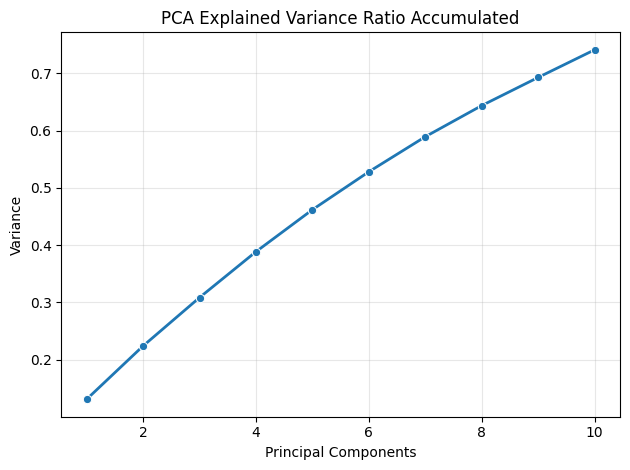

In [ ]:
# PCA analysis
weighted_pca = PCA(n_components=10)
weighted_pca_trained = weighted_pca.fit_transform(weighted_data)
weighted_trained_pca_df = pd.DataFrame(
    weighted_pca_trained[:, :3], columns=["PC1", "PC2", "PC3"]
)
print(
    "Total variance explained by PC1+PC2+PC3:",
    weighted_pca.explained_variance_ratio_[:3].sum(),
)
print(
    "Variance explained by each Principal Component:",
    weighted_pca.explained_variance_ratio_,
)
print("Accumulated Variance:", weighted_pca.explained_variance_ratio_.cumsum())

make_plot(
    plot_type="line",
    data=None,
    x_col=np.arange(1, 11),
    y_col=weighted_pca.explained_variance_ratio_.cumsum(),
    title="PCA Explained Variance Ratio Accumulated",
    xlabel="Principal Components",
    ylabel="Variance",
)

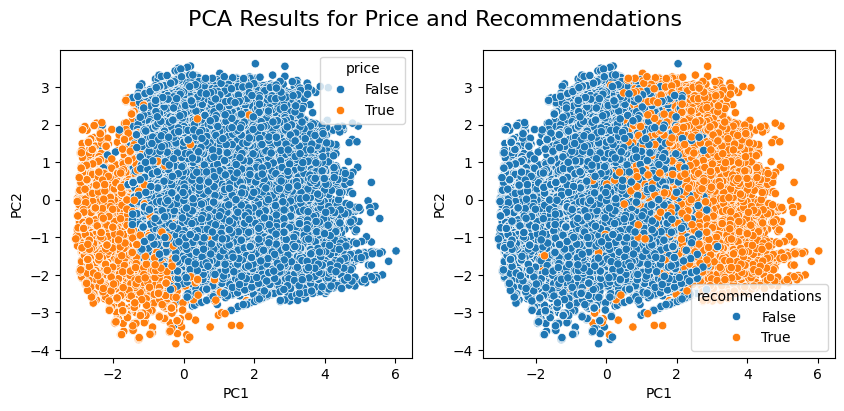

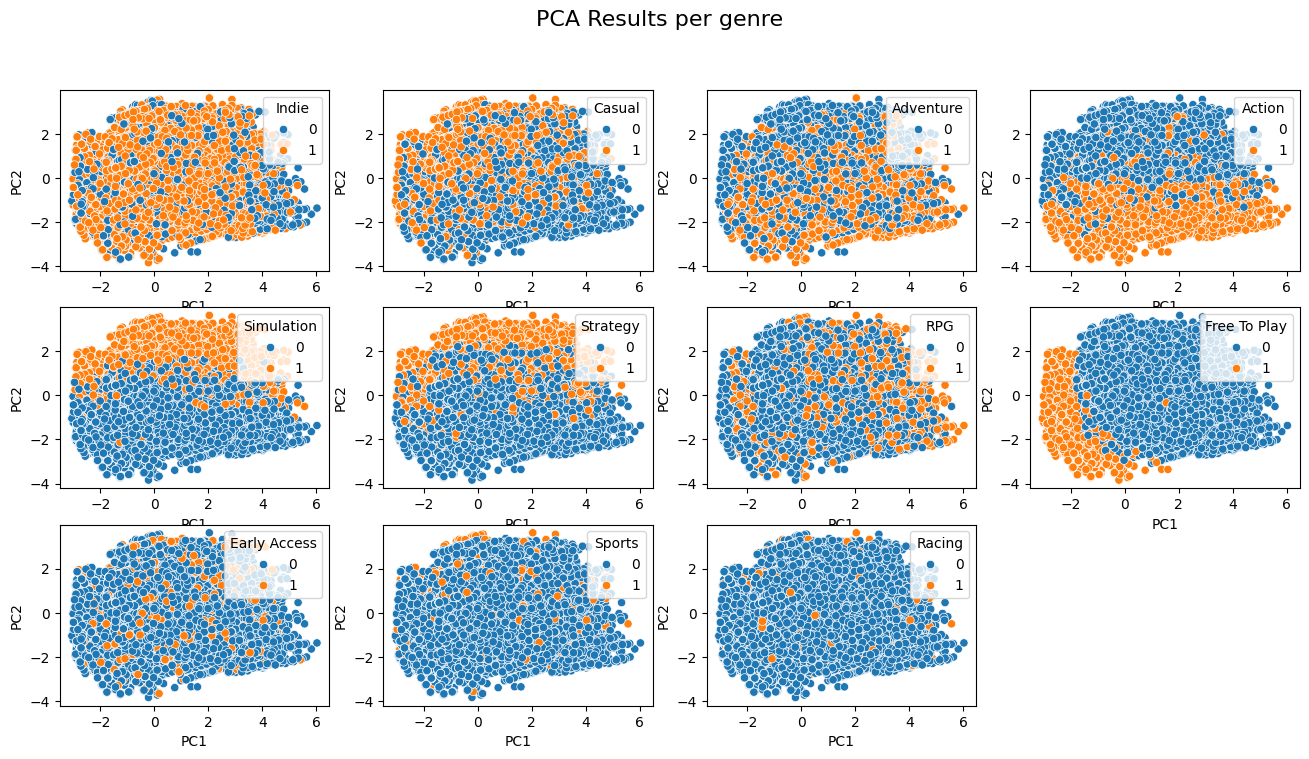

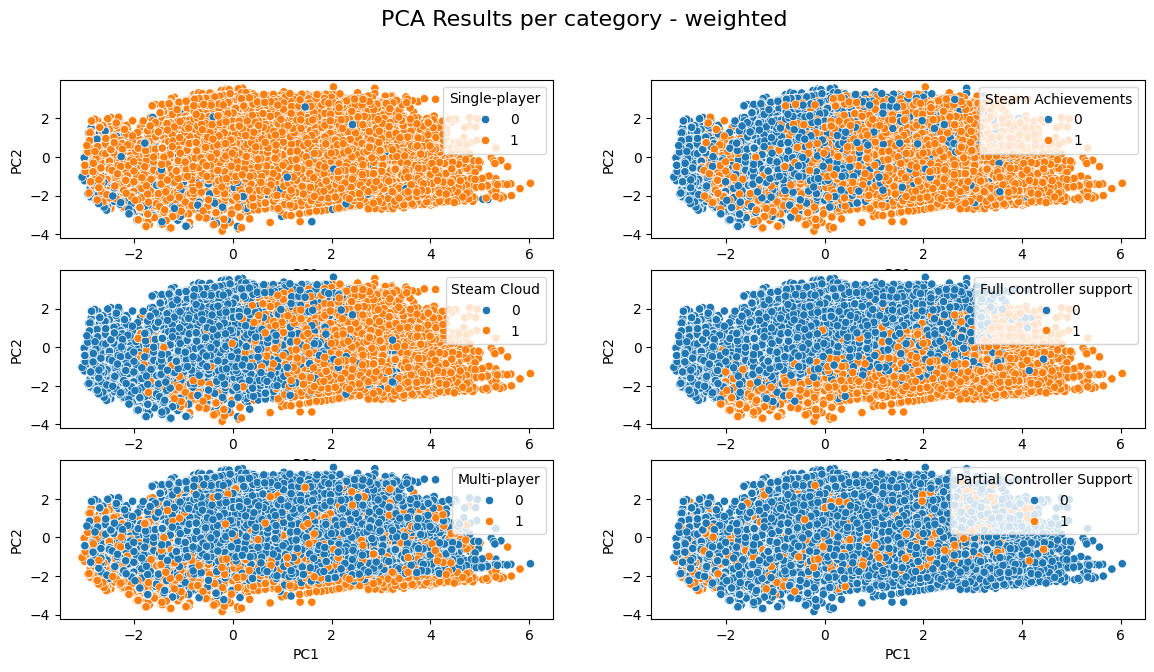

In [5]:
# PCA visualization per genre and category
multiple_scatterplot(
    data=weighted_trained_pca_df,
    title="PCA Results for Price and Recommendations",
    x_col="PC1",
    y_col="PC2",
    n=1,
    m=2,
    hue_values=discrete_variables,
    xsize=10,
    ysize=4,
)
multiple_scatterplot(
    data=weighted_trained_pca_df,
    title="PCA Results per genre",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=4,
    hue_values=genres,
    xsize=16,
    ysize=8,
)
multiple_scatterplot(
    data=weighted_trained_pca_df,
    title="PCA Results per category - weighted",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=2,
    hue_values=categories,
    xsize=14,
    ysize=7,
)

In [ ]:
# Execute elbow method and Silhouette Score
inertias = []
sil_scores_weighted = []
kmeans_range = range(1, 11)

for k in kmeans_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(weighted_data)
    inertias.append(km.inertia_)
    if k > 1:
        sil_scores_weighted.append(
            silhouette_score(weighted_data, km.labels_, n_jobs=-1)
        )

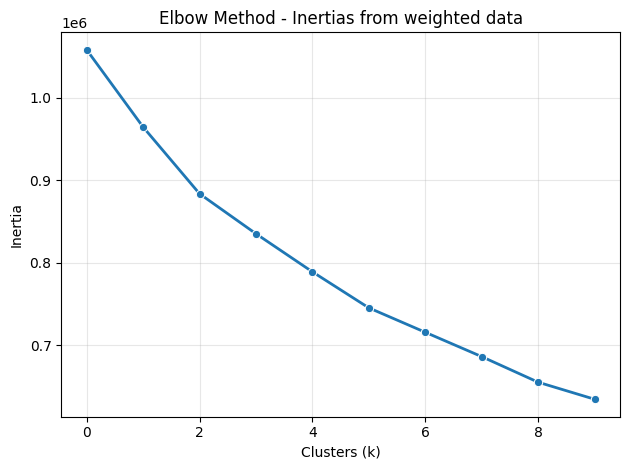

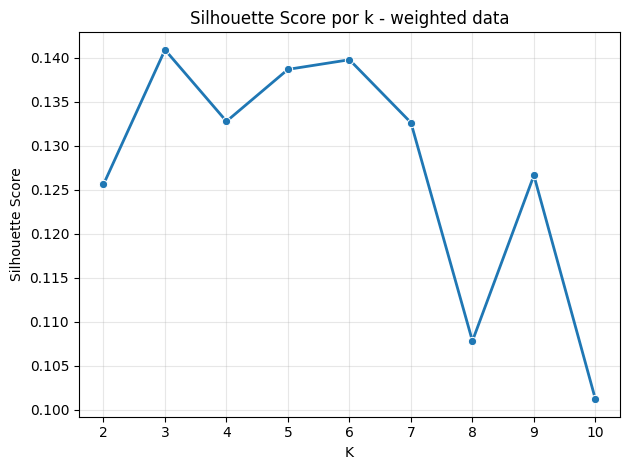

In [ ]:
# Visualize the elbow method and Silhouette Score
make_plot(
    plot_type="line",
    data=inertias,
    x_col=None,
    y_col=None,
    title="Elbow Method - Inertias from weighted data",
    xlabel="Clusters (k)",
    ylabel="Inertia",
    xticks=kmeans_range,
)
plt.show()

make_plot(
    plot_type="line",
    data=None,
    x_col=range(2, 11),
    y_col=sil_scores_weighted,
    title="Silhouette Score por k - weighted data",
    xlabel="K",
    ylabel="Silhouette Score",
)
plt.show()

In [ ]:
# Find optimal value of k for KMeans
kl_kmeans = KneeLocator(range(1, 11), inertias, curve="convex", direction="decreasing")
weighted_optimal_k = np.argmax(sil_scores_weighted) + 2
print(f"Optimal K (Elbow): {kl_kmeans.elbow}")
print(f"Optimal K (Silhouette): {weighted_optimal_k}")

Optimal K (Elbow): 4
Optimal K (Silhouette): 3


In [ ]:
# See what features influence more on each principal component
pca_loadings = pd.DataFrame(
    weighted_pca.components_.T[:, :3],
    columns=["PC1", "PC2", "PC3"],
    index=weighted_data.columns,
)
print(pca_loadings["PC1"].abs().sort_values(ascending=False).head(5))
print(pca_loadings["PC2"].abs().sort_values(ascending=False).head(5))
print(pca_loadings["PC3"].abs().sort_values(ascending=False).head(5))

price                      0.502221
Steam Cloud                0.440856
recommendations            0.405347
Free To Play               0.397360
Full controller support    0.331779
Name: PC1, dtype: float32
Simulation                 0.507544
Action                     0.439920
Full controller support    0.409995
Strategy                   0.390094
Free To Play               0.245732
Name: PC2, dtype: float32
Multi-player    0.658645
Early Access    0.427242
Strategy        0.300723
Sports          0.205108
Action          0.204560
Name: PC3, dtype: float32


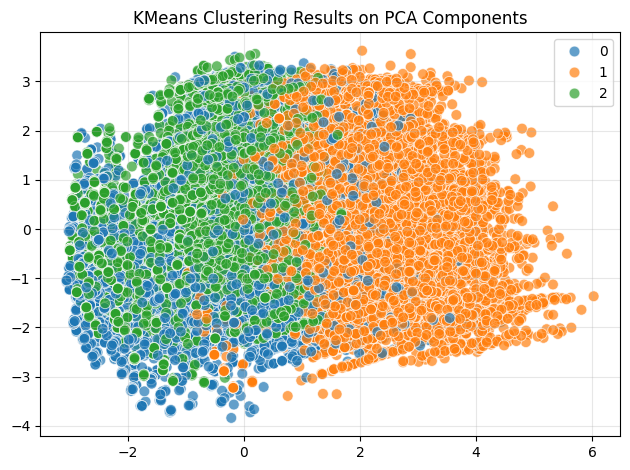

In [ ]:
# Train a KMEANS model
kmeans = KMeans(n_clusters=weighted_optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(weighted_data)
weighted_trained_pca_df["labels"] = kmeans_labels

make_plot(
    plot_type="scatter",
    data=weighted_trained_pca_df,
    title="KMeans Clustering Results on PCA Components",
    x_col="PC1",
    y_col="PC2",
    hue="labels",
    palette="tab10",
    legend=True,
    legend_label="Clusters",
)
plt.show()

# 3D visualization of PCA results with cluster labels
fig = px.scatter_3d(
    weighted_trained_pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="labels",
    title="PCA 3D Visualization",
)
centroids_cords = (
    weighted_trained_pca_df.groupby("labels")[["PC1", "PC2", "PC3"]]
    .mean()
    .reset_index()
)

fig.add_trace(  # Add centroids
    go.Scatter3d(
        x=centroids_cords["PC1"],
        y=centroids_cords["PC2"],
        z=centroids_cords["PC3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids_cords["labels"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()
fig.write_html(FSTMODEL_OUTPUT_PLOTS_PATH)

In [ ]:
# Analyce kmeans labels output
scaler = joblib.load(FE_OUTPUT_SCALER_PATH)
kmeans_centroids = kmeans.cluster_centers_

df_centroids = pd.DataFrame(
    kmeans_centroids,
    columns=weighted_data.columns,
    index=[f"Cluster {i}" for i in range(kmeans.n_clusters)],
)

# See mean value columns for cluster
for i in range(kmeans.n_clusters):
    top_genres = df_centroids.loc[f"Cluster {i}", weighted_data.columns].sort_values(
        ascending=False
    )
    print(f"\n--- Cluster {i} ---")
    price_recommendations = [
        [
            df_centroids.loc[f"Cluster {i}", "price"],
            df_centroids.loc[f"Cluster {i}", "recommendations"],
        ]
    ]
    print(f"Centroid mean price: {df_centroids.loc[f'Cluster {i}', 'price']}")
    print(f"Centroid mean recommendations: {df_centroids.loc[f'Cluster {i}', 'recommendations']}")
    print(f"Transformed price and recommendations: {scaler.inverse_transform(price_recommendations)}")
    print("Top genres/categories:")
    print(top_genres.head(10))


--- Cluster 0 ---
Centroid mean price: -0.13699324429035187
Centroid mean recommendations: -0.1403679996728897
Transformed price and recommendations: [[1.4439359 0.477073 ]]
Top genres/categories:
Multi-player     1.979262
Early Access     1.554329
Action           1.045579
Indie            0.915168
Single-player    0.831040
Casual           0.749076
Strategy         0.686073
Free To Play     0.655199
Adventure        0.610312
Simulation       0.556152
Name: Cluster 0, dtype: float32

--- Cluster 1 ---
Centroid mean price: 0.5654311180114746
Centroid mean recommendations: 0.692266047000885
Transformed price and recommendations: [[2.15631403 2.23680894]]
Top genres/categories:
Steam Cloud                2.131586
Steam Achievements         1.510546
Full controller support    1.101627
Single-player              1.032892
Indie                      0.965337
Adventure                  0.806070
Casual                     0.775737
Action                     0.741484
RPG                       

In [ ]:
# See the distribution of clusters in the dataset
weighted_data["cluster_kproto"] = kmeans_labels
print(weighted_data["cluster_kproto"].value_counts())

cluster_kproto
2    35841
1    16340
0    11814
Name: count, dtype: int64


In [ ]:
# label data
weighted_data["cluster_kproto"] = weighted_data["cluster_kproto"].replace(0, "Budget_Indie_CoopSolo")
weighted_data["cluster_kproto"] = weighted_data["cluster_kproto"].replace(1, "Solo_FullSupport")
weighted_data["cluster_kproto"] = weighted_data["cluster_kproto"].replace(2, "Niche_Budget")
weighted_data["cluster_kproto"] = weighted_data["cluster_kproto"].astype("category")

# Second Model Analysis and Training
- Encoded (OHE) genres and categories
- K-Prototypes model
- FAMD Visualization

Variance per dimension: [11.74763139  9.03860416  8.16879938]


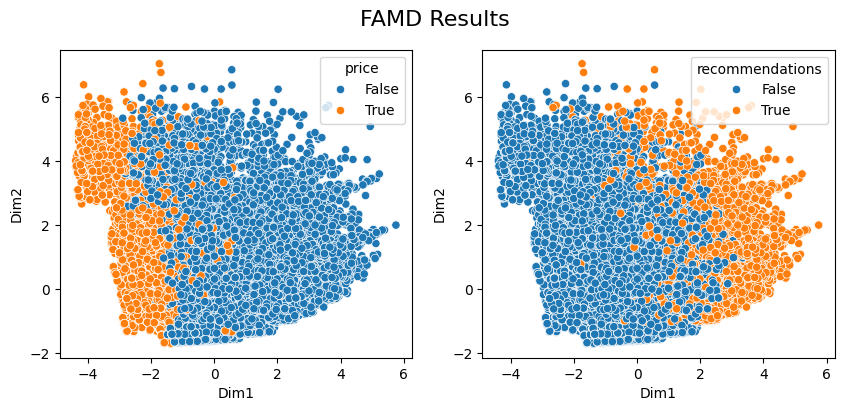

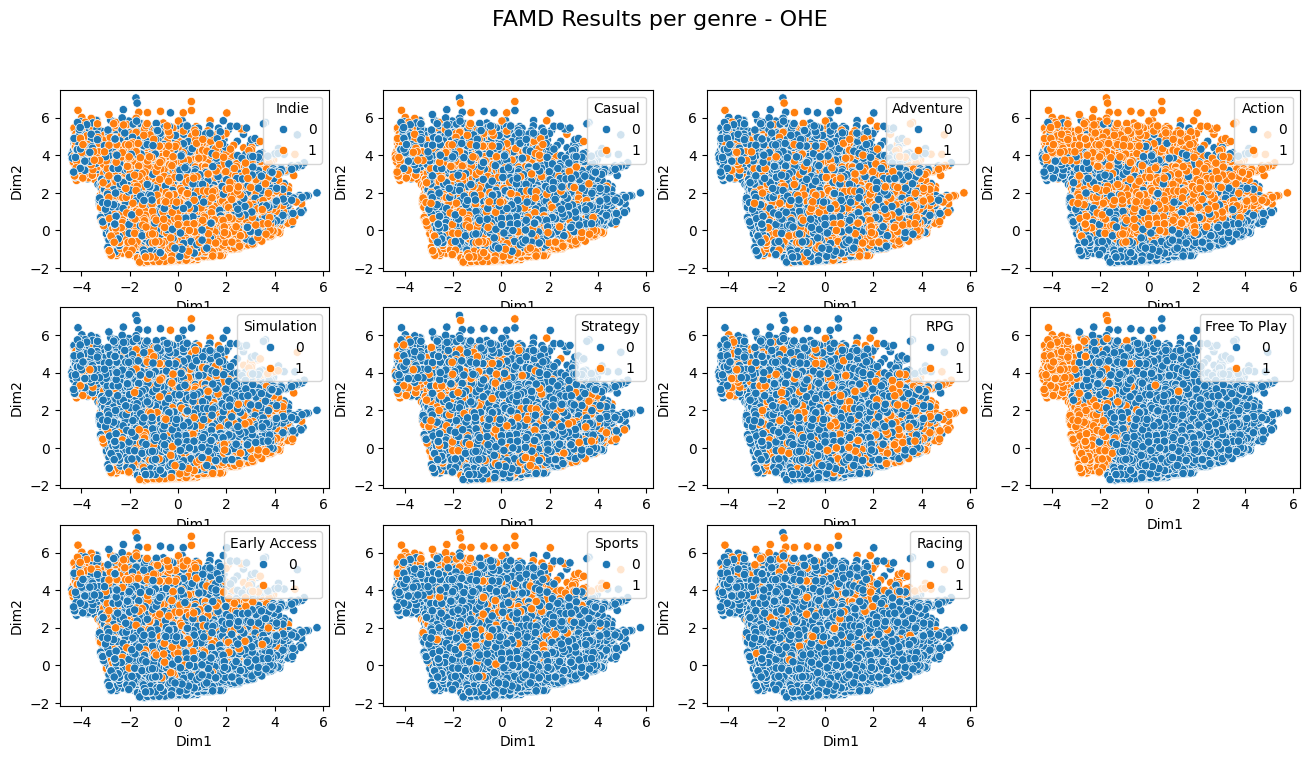

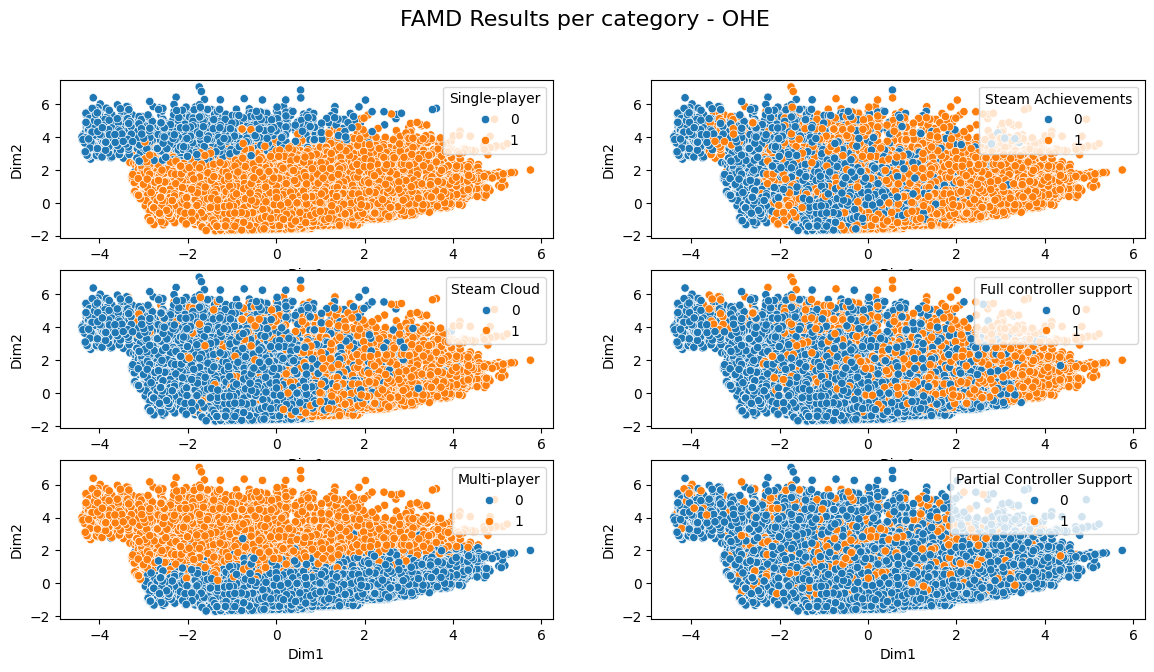

In [ ]:
# FAMD Visualization
data_famd = ohe_data.copy()
for column in categorical_cols:
    data_famd[column] = data_famd[column].astype("category")

ohe_data_matrix = data_famd.to_numpy()
famd = prince.FAMD(n_components=3, n_iter=3, random_state=42)
famd = famd.fit(data_famd)
coords = famd.row_coordinates(data_famd)
coords.columns = ["Dim1", "Dim2", "Dim3"]
coords.reset_index(drop=True, inplace=True)
print(f"Variance per dimension: {famd.percentage_of_variance_}")

multiple_scatterplot(
    data=coords,
    title="FAMD Results",
    x_col="Dim1",
    y_col="Dim2",
    n=1,
    m=2,
    hue_values=discrete_variables,
    xsize=10,
    ysize=4,
)
multiple_scatterplot(
    data=coords,
    title="FAMD Results per genre - OHE",
    x_col="Dim1",
    y_col="Dim2",
    n=3,
    m=4,
    hue_values=genres,
    xsize=16,
    ysize=8,
)
multiple_scatterplot(
    data=coords,
    title="FAMD Results per category - OHE",
    x_col="Dim1",
    y_col="Dim2",
    n=3,
    m=2,
    hue_values=categories,
    xsize=14,
    ysize=7,
)

In [ ]:
# See what features influence more on each dimension of FAMD
contributions = famd.column_contributions_
print(f"Contributions at dimension 0: {contributions[0].sort_values(ascending=False).head(5)}")
print(f"Contributions at dimension 1: {contributions[1].sort_values(ascending=False).head(5)}")
print(f"Contributions at dimension 2: {contributions[2].sort_values(ascending=False).head(5)}")

Contributions at dimension 0: variable
price                 0.228779
Steam Cloud           0.169203
Free To Play          0.150539
recommendations       0.137466
Steam Achievements    0.133506
Name: 0, dtype: float64
Contributions at dimension 1: variable
Multi-player     0.336569
Single-player    0.218268
Action           0.147128
Early Access     0.052285
Casual           0.050232
Name: 1, dtype: float64
Contributions at dimension 2: variable
Simulation    0.202949
Adventure     0.142836
Sports        0.131807
Action        0.114038
Strategy      0.107718
Name: 2, dtype: float64


k=2 -> cost=178295.22
k=3 -> cost=140487.57
k=4 -> cost=129293.43
k=5 -> cost=122665.66
k=6 -> cost=116516.01
k=7 -> cost=113031.29
k=8 -> cost=109336.38
k=9 -> cost=106484.73
k=10 -> cost=103499.22


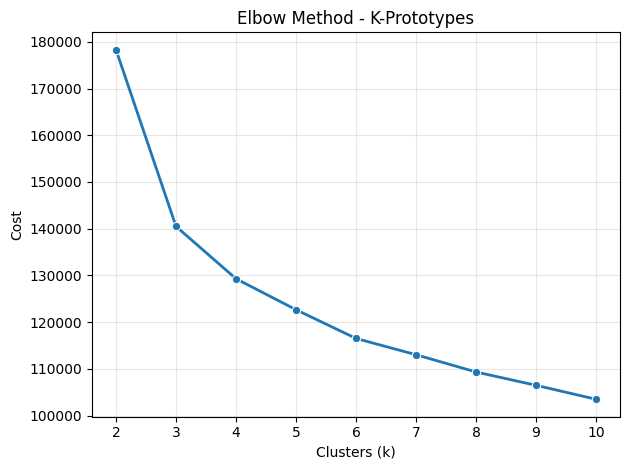

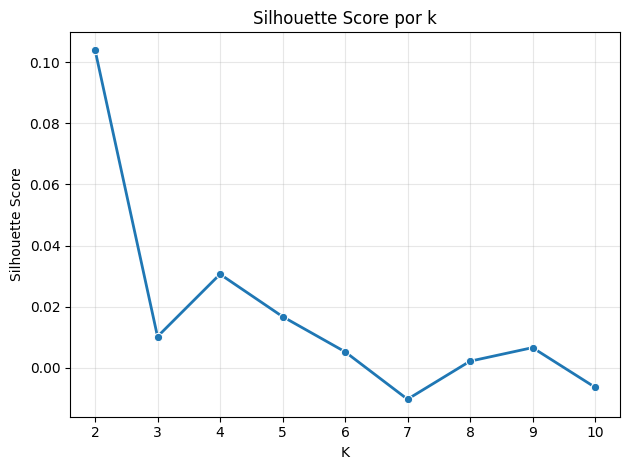

In [ ]:
# Find optimal value of k for KPrototypes using the elbow method and Silhouette Score
costs = []
sil_scores_ohe = []
Kprototypes_range = range(2, 11)

for k in Kprototypes_range:
    kproto = KPrototypes(
        n_clusters=k, init="Huang", n_init=10, random_state=42, verbose=0, n_jobs=-1
    )

    kproto.fit_predict(ohe_data_matrix, categorical=categorical_values)
    costs.append(kproto.cost_)
    print(f"k={k} -> cost={kproto.cost_:.2f}")

    # Use Gower distances with random sampling to test k with silhouette score.
    df_sample, _, labels_sample, _ = train_test_split(
        ohe_data,
        kproto.labels_,
        train_size=6000,
        stratify=kproto.labels_,
        random_state=42,
    )
    dist_matrix = gower.gower_matrix(df_sample)
    sil_scores_ohe.append(silhouette_score(dist_matrix, labels_sample, n_jobs=-1))

In [ ]:
# Visualize the elbow method and Silhouette Score
make_plot(
    plot_type="line",
    data=None,
    x_col=list(Kprototypes_range),
    y_col=costs,
    title="Elbow Method - K-Prototypes",
    xlabel="Clusters (k)",
    ylabel="Cost",
)
plt.show()

make_plot(
    plot_type="line",
    data=None,
    x_col=range(2, 11),
    y_col=sil_scores_ohe,
    title="Silhouette Score por k",
    xlabel="K",
    ylabel="Silhouette Score",
)
plt.show()

In [ ]:
# Detect the optimal K value for KPrototypes
kl_prototypes = KneeLocator(
    list(Kprototypes_range), costs, curve="convex", direction="decreasing"
)
ohe_optimal_k = np.argmax(sil_scores_ohe) + 2
print(f"Optimal K (Elbow): {kl_prototypes.elbow}")
print(f"Optimal K (Silhouette): {ohe_optimal_k}")

Optimal K (Elbow): 4
Optimal K (Silhouette): 2


In [ ]:
# Train optimal KPrototypes model
kproto = KPrototypes(
    n_clusters=3,
    init="Huang",
    n_init=20,  # Final model, high n_init
    gamma=None,
    random_state=42,
    verbose=0,
    n_jobs=-1,
)
clusters = kproto.fit_predict(ohe_data_matrix, categorical=categorical_values)
coords["cluster"] = clusters
print("Model final cost:", kproto.cost_)

Model final cost: 140487.57018057993


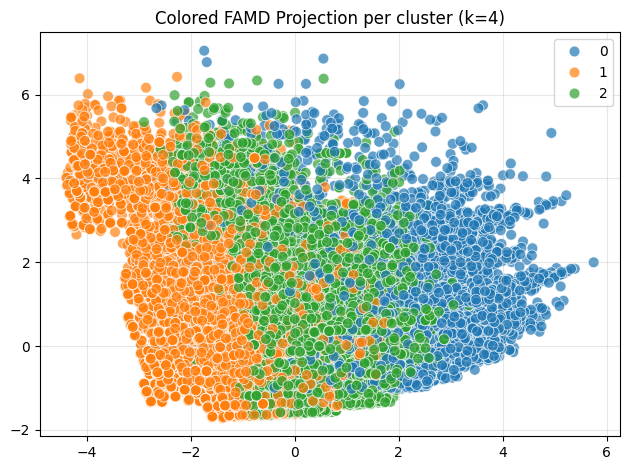

In [ ]:
# Visualize 3D FAMD results with cluster labels
fig = px.scatter_3d(coords, x="Dim1", y="Dim2", z="Dim3", color="cluster", title="FAMD 3D Visualization")
centroids_cords_FAMD = (coords.groupby("cluster")[["Dim1", "Dim2", "Dim3"]].mean().reset_index())

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids_cords_FAMD["Dim1"],
        y=centroids_cords_FAMD["Dim2"],
        z=centroids_cords_FAMD["Dim3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids_cords_FAMD["cluster"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()
fig.write_html(SNDMODEL_OUTPUT_PLOTS_PATH)

# 2 Dimenntional FAMD visualization with clusters
make_plot(
    plot_type="scatter",
    data=coords,
    title=f"Colored FAMD Projection per cluster (k={4})",
    x_col="Dim1",
    y_col="Dim2",
    hue="cluster",
    palette="tab10",
    legend=True,
    legend_label="Cluster Labels",
)
plt.show()

In [ ]:
famd_df_centroids = pd.DataFrame(
    kproto.cluster_centroids_,
    columns=ohe_data.columns,
    index=[f"Cluster {i}" for i in range(kproto.n_clusters)],
)

# See mean value columns for cluster
for i in range(kproto.n_clusters):
    top_genres = famd_df_centroids.loc[f"Cluster {i}", ohe_data.columns].sort_values(
        ascending=False
    )
    print(f"\n--- Cluster {i} ---")
    price_recommendations = [
        [
            famd_df_centroids.loc[f"Cluster {i}", "price"],
            famd_df_centroids.loc[f"Cluster {i}", "recommendations"],
        ]
    ]
    print(f"Centroid mean price: {price_recommendations[0][0]}")
    print(f"Centroid mean recommendations: {price_recommendations[0][1]}")
    print(f"Transformed price and recommendations: {scaler.inverse_transform(price_recommendations)}")
    print("Top genres/categories:")
    print(top_genres)


--- Cluster 0 ---
Centroid mean price: 0.8344991444250546
Centroid mean recommendations: 2.5838606976516805
Transformed price and recommendations: [[2.42919491 6.23461218]]
Top genres/categories:
recommendations               2.583861
Indie                         1.000000
Single-player                 1.000000
Steam Achievements            1.000000
Steam Cloud                   1.000000
price                         0.834499
Casual                        0.000000
Strategy                      0.000000
Adventure                     0.000000
Action                        0.000000
Simulation                    0.000000
Early Access                  0.000000
Free To Play                  0.000000
RPG                           0.000000
Racing                        0.000000
Sports                        0.000000
Full controller support       0.000000
Multi-player                  0.000000
Partial Controller Support    0.000000
Name: Cluster 0, dtype: float64

--- Cluster 1 ---
Centroid me

In [ ]:
# See the distribution of clusters in the dataset
ohe_data["cluster_kproto"] = clusters
print(ohe_data["cluster_kproto"].value_counts())

cluster_kproto
2    31807
1    24274
0     7914
Name: count, dtype: int64


In [ ]:
# label data
ohe_data["cluster_kproto"] = ohe_data["cluster_kproto"].replace(0, "Prosperous")
ohe_data["cluster_kproto"] = ohe_data["cluster_kproto"].replace(1, "f2p Casual")
ohe_data["cluster_kproto"] = ohe_data["cluster_kproto"].replace(2, "Basic Budget")
ohe_data["cluster_kproto"] = ohe_data["cluster_kproto"].astype("category")

# Outputs

In [ ]:
# Dataframes
weighted_data.to_parquet(f"{WEIGHTED_DATAFRAME_LABELLED}", index=True)
ohe_data.to_parquet(f"{OHE_DATAFRAME_LABELLED}", index=True)

# Kmeans and KPrototypes models
joblib.dump(kmeans, f"{WEIGHTED__MODEL_PATH}")
joblib.dump(kproto, f"{OHE_MODEL_PATH}")